# V13 – Rechnerarchitektur: Aufgaben

## 🎯 Lernziele
In diesen fünf Aufgaben wendest du die matplotlib-Basics aus `02_praxis.ipynb` auf typische Maschinenbau-Daten an und verknüpfst sie mit Kontrollfluss-Grundlagen aus V05/V06.

- Balkendiagramme mit Beschriftung erstellen.
- Einfache Statistik-Funktionen (Mittelwert) selbst schreiben.
- Fallunterscheidungen (Ausschuss-Kategorien) programmieren.
- Messwerte aus **Listen** skalieren.
- Echte **CSV-Dateien** einlesen und auswerten.

## ⏱️ Zeitbudget
Ca. 45 Minuten.

## 🧭 TL;DR
Fünf Aufgaben, drei ⭐ und zwei ⭐⭐. Jede Aufgabe hat Starter-Code (mit `# TODO`) und eine eigene Selbstkontroll-Zelle. Du musst nichts neu anlegen – nur die TODOs füllen. Für Aufgabe 4 und 5 gibt es einen Programmablaufplan (PAP).

## 🧪 Testdaten
- `lager_vibrationsdaten.csv` (liegt **direkt im Vorlesungsordner**) – wird in Aufgabe 5 eingelesen.

## 📦 Voraussetzungen
- V13 Theorie + Praxis (`01_theorie.ipynb`, `02_praxis.ipynb`)
- V05/V06 (`if/elif/else`, `for`-Schleifen)
- V10 (Funktionen mit `def`/`return`)


In [1]:
# Gemeinsame Imports für alle Aufgaben in diesem Notebook.
import matplotlib.pyplot as plt
import csv
import os

print("Notebook bereit. CSV gefunden:", os.path.exists("lager_vibrationsdaten.csv"))


Notebook bereit. CSV gefunden: True


## Aufgabe 1 ⭐ – CNC-Werkzeugverschleiß visualisieren

**Kontext.** Du hast für fünf Werkzeuge einer CNC-Fräse den Verschleiß in Millimetern nach einer Schicht gemessen:

```
verschleiss = [0.12, 0.18, 0.25, 0.31, 0.45]   # W1 … W5
```

**Aufgabe.** Erstelle ein **Balkendiagramm** mit den fünf Werkzeugnamen `"W1"` … `"W5"` auf der X-Achse und den Verschleißwerten auf der Y-Achse. Setze:

- Titel: `"Werkzeugverschleiß nach einer Schicht"`
- X-Achse: `"Werkzeug"`
- Y-Achse: `"Verschleiß in mm"`

**Erwartete Ausgabe.** Ein Plot mit fünf Balken, steigendem Verlauf, vollständiger Beschriftung.


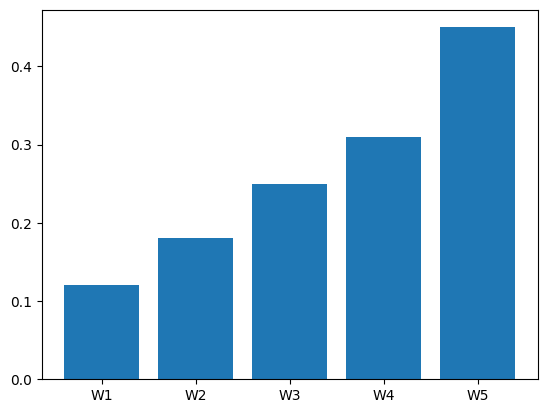

In [2]:
import matplotlib.pyplot as plt

werkzeuge = ["W1", "W2", "W3", "W4", "W5"]
verschleiss = [0.12, 0.18, 0.25, 0.31, 0.45]

plt.figure()
# TODO: Zeichne das Balkendiagramm und setze Titel + Achsenbeschriftungen.
plt.bar(werkzeuge, verschleiss)
plt.title("")    # TODO
plt.xlabel("")   # TODO
plt.ylabel("")   # TODO

a1_titel = plt.gca().get_title()
a1_xlabel = plt.gca().get_xlabel()
a1_ylabel = plt.gca().get_ylabel()
plt.show()


In [3]:
# ▶️ Selbstkontrolle Aufgabe 1
try:
    assert len(verschleiss) == 5, "Liste muss 5 Werte haben."
    assert a1_titel == "Werkzeugverschleiß nach einer Schicht", \
        f"Titel falsch: '{a1_titel}'"
    assert a1_xlabel == "Werkzeug", f"xlabel falsch: '{a1_xlabel}'"
    assert a1_ylabel == "Verschleiß in mm", f"ylabel falsch: '{a1_ylabel}'"
    print("✅ Aufgabe 1 gelöst.")
except AssertionError as e:
    print("❌ Aufgabe 1 – noch nicht richtig:", e)
except NameError as e:
    print("❌ Aufgabe 1 – Variable fehlt:", e)


❌ Aufgabe 1 – noch nicht richtig: Titel falsch: ''


## Aufgabe 2 ⭐ – Hydraulikdruck-Mittelwert

**Kontext.** An einer Hydraulikpresse wurden in sechs aufeinanderfolgenden Takten die folgenden Drücke (in bar) gemessen:

```
drucke = [180, 190, 175, 185, 195, 182]
```

**Aufgabe.** Schreibe eine Funktion `mittelwert(liste)`, die den arithmetischen **Mittelwert** einer Liste von Zahlen zurückgibt, also `sum(liste) / len(liste)`.

**Erwartete Ausgabe.** `mittelwert(drucke)` ergibt **184.5**.


In [4]:
def mittelwert(liste):
    # TODO: Mittelwert zurückgeben (sum / len). Aktuell Default 0.0.
    return 0.0

drucke = [180, 190, 175, 185, 195, 182]
m = mittelwert(drucke)
print("Mittelwert:", m, "bar")


Mittelwert: 0.0 bar


In [5]:
# ▶️ Selbstkontrolle Aufgabe 2
try:
    assert abs(mittelwert([180, 190, 175, 185, 195, 182]) - 184.5) < 0.01, \
        "Mittelwert der Drucke muss 184.5 sein."
    assert abs(mittelwert([10, 20, 30]) - 20.0) < 0.01, \
        "Mittelwert von [10,20,30] muss 20 sein."
    assert abs(mittelwert([5.0]) - 5.0) < 0.01, "Mittelwert einer 1-elementigen Liste ist der Wert selbst."
    print("✅ Aufgabe 2 gelöst.")
except AssertionError as e:
    print("❌ Aufgabe 2 – noch nicht richtig:", e)
except NameError as e:
    print("❌ Aufgabe 2 – Funktion fehlt:", e)
except ZeroDivisionError as e:
    print("❌ Aufgabe 2 – Achtung, leere Liste? Erstmal sum/len testen:", e)


❌ Aufgabe 2 – noch nicht richtig: Mittelwert der Drucke muss 184.5 sein.


## Aufgabe 3 ⭐ – Produktionsqualität kategorisieren

**Kontext.** In der Fertigung wird die Ausschussrate in Prozent gemessen. Sie soll automatisch in vier **Qualitätskategorien** einsortiert werden:

| Ausschussrate `rate`    | Kategorie |
|-------------------------|-----------|
| `rate < 2`              | `"E1"`    |
| `2 <= rate < 5`         | `"E2"`    |
| `5 <= rate < 10`        | `"E3"`    |
| `rate >= 10`            | `"E4"`    |

**Aufgabe.** Schreibe eine Funktion `kategorie(rate)`, die anhand der Tabelle den passenden String zurückgibt. Nutze `if` / `elif` / `else`.

**Erwartete Ausgabe.** `kategorie(1.5) == "E1"`, `kategorie(3.0) == "E2"`, `kategorie(7.5) == "E3"`, `kategorie(12.0) == "E4"`.


In [6]:
def kategorie(rate):
    # TODO: Fallunterscheidung passend zur Tabelle. Default "E4" als sicherer Rückgabewert.
    return "E4"

for r in [1.5, 3.0, 7.5, 12.0]:
    print(f"rate={r}  ->  {kategorie(r)}")


rate=1.5  ->  E4
rate=3.0  ->  E4
rate=7.5  ->  E4
rate=12.0  ->  E4


In [7]:
# ▶️ Selbstkontrolle Aufgabe 3
try:
    assert kategorie(0.5) == "E1", "rate=0.5 muss 'E1' sein."
    assert kategorie(1.99) == "E1", "rate=1.99 muss 'E1' sein."
    assert kategorie(2.0) == "E2", "rate=2.0 muss 'E2' sein."
    assert kategorie(4.9) == "E2", "rate=4.9 muss 'E2' sein."
    assert kategorie(5.0) == "E3", "rate=5.0 muss 'E3' sein."
    assert kategorie(9.9) == "E3", "rate=9.9 muss 'E3' sein."
    assert kategorie(10.0) == "E4", "rate=10.0 muss 'E4' sein."
    assert kategorie(25.0) == "E4", "rate=25.0 muss 'E4' sein."
    print("✅ Aufgabe 3 gelöst.")
except AssertionError as e:
    print("❌ Aufgabe 3 – noch nicht richtig:", e)
except NameError as e:
    print("❌ Aufgabe 3 – Funktion fehlt:", e)


❌ Aufgabe 3 – noch nicht richtig: rate=0.5 muss 'E1' sein.


## Aufgabe 4 ⭐⭐ – FEM-Spannungen skalieren

**Kontext.** In einer FEM-Simulation (*Finite-Elemente-Methode*) werden an vier Knoten eines Bauteils Spannungen in MPa berechnet. Das Ergebnis soll mit einem **Sicherheitsfaktor** skaliert werden (z. B. `faktor=1.5`), um Lastreserven zu bewerten.

**Aufgabe.** Schreibe eine Funktion `spannungen_skaliert(werte, faktor)`, die eine **neue Liste** zurückgibt. Jedes Element ist `wert * faktor`, auf **2 Nachkommastellen gerundet** (`round(..., 2)`).

**Erwartete Ausgabe.** `spannungen_skaliert([100.0, 150.5, 200.25, 180.1], 1.5)` liefert `[150.0, 225.75, 300.38, 270.15]`.


### 🧭 Programmablaufplan (PAP)

Der PAP zu Aufgabe 4 liegt als eigene Datei unter [diagramme/aufgabe_4_pap.mmd](diagramme/aufgabe_4_pap.mmd). Er wird in der folgenden Zelle geladen und gerendert.


In [8]:
from IPython.display import Markdown, display

with open("diagramme/aufgabe_4_pap.mmd", encoding="utf-8") as f:
    display(Markdown(f"```mermaid\n{f.read()}\n```"))


```mermaid
flowchart TD
    S(["Start"]) --> I["produziert = [...]<br/>ausschuss = [...]<br/>schichten = [...]"]
    I --> Q["quote = []"]
    Q --> L{"fuer i in range(len(schichten))"}
    L -- "naechste Schicht" --> R["q = ausschuss[i] / produziert[i] * 100<br/>quote.append(round(q, 2))"]
    R --> L
    L -- "fertig" --> P["plt.bar(schichten, quote)<br/>plt.title(...)<br/>plt.xlabel(...)<br/>plt.ylabel(...)<br/>plt.show()"]
    P --> E(["Ende"])

```

In [9]:
def spannungen_skaliert(werte, faktor):
    # TODO: Jede Zahl aus 'werte' mit 'faktor' multiplizieren, auf 2 Stellen runden,
    #       und als neue Liste zurückgeben. Aktueller Default: unveränderte Liste.
    return list(werte)

werte = [100.0, 150.5, 200.25, 180.1]
print("Skaliert mit 1.5 :", spannungen_skaliert(werte, 1.5))


Skaliert mit 1.5 : [100.0, 150.5, 200.25, 180.1]


In [10]:
# ▶️ Selbstkontrolle Aufgabe 4
try:
    erg = spannungen_skaliert([100.0, 150.5, 200.25, 180.1], 1.5)
    assert erg == [150.0, 225.75, 300.38, 270.15], f"Unerwartetes Ergebnis: {erg}"
    erg2 = spannungen_skaliert([10.0, 20.0], 2.0)
    assert erg2 == [20.0, 40.0], f"Erwartet [20.0, 40.0], bekommen {erg2}"
    erg3 = spannungen_skaliert([1.234, 5.678], 1.0)
    assert erg3 == [1.23, 5.68], f"Rundung auf 2 Stellen fehlt. Bekommen: {erg3}"
    print("✅ Aufgabe 4 gelöst.")
except AssertionError as e:
    print("❌ Aufgabe 4 – noch nicht richtig:", e)
except NameError as e:
    print("❌ Aufgabe 4 – Funktion fehlt:", e)
except TypeError as e:
    print("❌ Aufgabe 4 – Typfehler (rufst du round richtig auf?):", e)


❌ Aufgabe 4 – noch nicht richtig:

 Unerwartetes Ergebnis: [100.0, 150.5, 200.25, 180.1]


## Aufgabe 5 ⭐⭐ – Lager-Schwingungen aus CSV auswerten

**Kontext.** Die Datei `lager_vibrationsdaten.csv` enthält Messwerte von Kugellagern unter verschiedenen Betriebszuständen. Die Spalten sind (mit Kopfzeile):

```
Drehzahl_UPM,Zustand,Amplitude_mm_s,Temperatur_C,Betriebsstunden
```

Uns interessiert die **dritte Spalte**: `Amplitude_mm_s` (Schwingungsamplitude in mm/s).

**Aufgabe.** Schreibe eine Funktion `amplituden_statistik(pfad)`, die die CSV öffnet, die Kopfzeile überspringt und aus **allen** Amplituden-Werten ein Dictionary zurückgibt:

```python
{"min": <Minimum>, "max": <Maximum>, "mittelwert": <Mittelwert>}
```

Alle drei Werte sind auf **2 Nachkommastellen** gerundet.

**Hinweise.**
- Einlesen z. B. mit `csv.reader`, dann `next(reader)` um die Kopfzeile zu überspringen.
- Jeder Zeilenwert kommt als String – Amplitude mit `float(zeile[2])` umwandeln.
- Du darfst `min()`, `max()`, `sum()`, `len()` verwenden.

**Erwartete Ausgabe.** Beispielhafter Aufruf gibt ein Dict zurück, dessen Werte der Selbstcheck gegen die aus der CSV berechneten Werte prüft.


### 🧭 Programmablaufplan (PAP)

Der PAP zu Aufgabe 5 liegt als eigene Datei unter [diagramme/aufgabe_5_pap.mmd](diagramme/aufgabe_5_pap.mmd). Er wird in der folgenden Zelle geladen und gerendert.


In [11]:
from IPython.display import Markdown, display

with open("diagramme/aufgabe_5_pap.mmd", encoding="utf-8") as f:
    display(Markdown(f"```mermaid\n{f.read()}\n```"))


```mermaid
flowchart TD
    S(["Start"]) --> O["CSV mit open(...) lesen<br/>Header ueberspringen"]
    O --> I["summe = {Neu:0, Leicht_verschlissen:0,<br/>Stark_verschlissen:0, Beschaedigt:0}<br/>anzahl = {... : 0, ...}"]
    I --> L{"fuer jede Zeile"}
    L -- "naechste Zeile" --> P["spalten = zeile.split(',')<br/>zustand = spalten[1]<br/>amp = float(spalten[2])"]
    P --> A["summe[zustand] += amp<br/>anzahl[zustand] += 1"]
    A --> L
    L -- "fertig" --> M["mittel = [summe[z]/anzahl[z]<br/>fuer z in zustaende]"]
    M --> B["plt.bar(zustaende, mittel)<br/>plt.title / xlabel / ylabel<br/>plt.show()"]
    B --> E(["Ende"])

```

In [12]:
import csv

def amplituden_statistik(pfad):
    # TODO: Datei öffnen, Header überspringen, Amplituden (Spalte 2) einsammeln,
    #       dann min/max/mittelwert auf 2 Stellen gerundet als Dict zurückgeben.
    # Sicherer Default, damit die Zelle ohne Fehler läuft:
    return {"min": 0.0, "max": 0.0, "mittelwert": 0.0}

print(amplituden_statistik("lager_vibrationsdaten.csv"))


{'min': 0.0, 'max': 0.0, 'mittelwert': 0.0}


In [13]:
# ▶️ Selbstkontrolle Aufgabe 5
# Referenz-Werte werden unabhängig aus der CSV berechnet, damit der Check
# robust gegen kleine Änderungen der Datei bleibt.
import csv

try:
    with open("lager_vibrationsdaten.csv", encoding="utf-8") as _f:
        _reader = csv.reader(_f)
        next(_reader)
        _amps = [float(z[2]) for z in _reader if z]
    _erw = {
        "min": round(min(_amps), 2),
        "max": round(max(_amps), 2),
        "mittelwert": round(sum(_amps) / len(_amps), 2),
    }

    erg = amplituden_statistik("lager_vibrationsdaten.csv")
    assert isinstance(erg, dict), f"Rückgabe muss ein dict sein, nicht {type(erg).__name__}."
    assert set(erg.keys()) == {"min", "max", "mittelwert"}, \
        f"Schlüssel müssen min/max/mittelwert sein, sind: {set(erg.keys())}"
    assert erg["min"] == _erw["min"], f"min falsch: erwartet {_erw['min']}, bekommen {erg['min']}"
    assert erg["max"] == _erw["max"], f"max falsch: erwartet {_erw['max']}, bekommen {erg['max']}"
    assert erg["mittelwert"] == _erw["mittelwert"], \
        f"mittelwert falsch: erwartet {_erw['mittelwert']}, bekommen {erg['mittelwert']}"
    print("✅ Aufgabe 5 gelöst. Erwartet:", _erw)
except AssertionError as e:
    print("❌ Aufgabe 5 – noch nicht richtig:", e)
except NameError as e:
    print("❌ Aufgabe 5 – Funktion fehlt:", e)
except FileNotFoundError as e:
    print("❌ Aufgabe 5 – CSV nicht gefunden:", e)


❌ Aufgabe 5 – noch nicht richtig: min falsch: erwartet 0.18, bekommen 0.0


## ✅ Zusammenfassung
- Du hast **Balkendiagramme** mit vollständiger Beschriftung erstellt (A1).
- Du hast eine einfache **Statistik-Funktion** geschrieben (A2) und eine **mehrstufige Fallunterscheidung** (A3).
- Du hast **Listen** komponenten­weise mit einem Faktor **skaliert** und gerundet (A4).
- Du hast eine echte **CSV-Datei** eingelesen und daraus Kennzahlen berechnet (A5).

## ➡️ Nächster Schritt
Vergleiche deine Lösungen mit dem Ordner [loesungen/](loesungen/). **Erst nach** eigenem Versuch reinschauen – dort ist jede Aufgabe Schritt für Schritt gelöst.
